In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

# Paths proyecto
PROJECT_DIR = Path.cwd().parent
SCRIPTS_DIR = PROJECT_DIR / "scripts"
DATA_PROCESSED_DIR = PROJECT_DIR / "data_processed"
OUTPUT_DIR = PROJECT_DIR / "outputs"

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))

from toxicity import (
    load_game_words,
    prepare_lol_toxicity_lexicons,
    apply_basic_toxicity_to_dataframe,
    apply_advanced_toxicity_to_dataframe,
)

In [2]:
df = pd.read_csv(DATA_PROCESSED_DIR / "reddit_with_vad.csv")

import ast
for col in ["tokens", "tokens_no_stop"]:
    df[col] = df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

df.head()


,body,created_utc,score,created_dt,date,year,month,year_month,text_clean,tokens,tokens_no_stop,n_tokens,n_tokens_no_stop,n_chars,vad_valence_mean,vad_arousal_mean,vad_dominance_mean
0,Done - your wish is our command. Graves shall...,2017-04-01 16:01:43,2022,2017-04-01 16:01:43,2017-04-01,2017,4,2017-04,done your wish is our command graves shall onc...,"[done, your, wish, is, our, command, graves, s...","[wish, command, graves, shall, puffing, fat, s...",28,11,134,0.028800,0.109800,0.097600
1,I don't play league but goddam it if I'm not g...,2017-04-01 03:56:12,4183,2017-04-01 03:56:12,2017-04-01,2017,4,2017-04,i don t play league but goddam it if i m not g...,"[i, don, t, play, league, but, goddam, it, if,...","[play, league, goddam, gonna, upvote, dreams, ...",25,10,115,0.327889,0.068222,0.133444
2,http://imgur.com/a/8F7c6 WE DID IT REDDIT!,2017-04-01 04:01:06,267,2017-04-01 04:01:06,2017-04-01,2017,4,2017-04,http imgur com a 8f7c6 we did it reddit,"[http, imgur, com, a, 8f7c6, we, did, it, reddit]","[imgur, 8f7c6, did, reddit]",9,4,42,0.000000,0.667000,0.000000
3,Seems legit,2017-04-01 00:55:50,978,2017-04-01 00:55:50,2017-04-01,2017,4,2017-04,seems legit,"[seems, legit]",[legit],2,1,11,0.494000,-0.146000,0.698000
4,"Graves no cigar, graves in peril, not to worry...",2017-04-01 01:19:17,670,2017-04-01 01:19:17,2017-04-01,2017,4,2017-04,graves no cigar graves in peril not to worry w...,"[graves, no, cigar, graves, in, peril, not, to...","[graves, cigar, graves, peril, worry, marc, me...",13,7,69,-0.598000,0.432667,-0.246000


In [3]:
GAMEWORDS_PATH = OUTPUT_DIR / "game_mechanics_words.json"
game_words = load_game_words(GAMEWORDS_PATH)
len(game_words), list(game_words)[:20]


(43,
 ['ff',
  'support',
  'farming',
  'nashor',
  'dead',
  'tower',
  'die',
  'killed',
  'surrender',
  'roam',
  'farm',
  'cs',
  'rift',
  'gg',
  'jg',
  'mid',
  'wave',
  'dying',
  'inting',
  'executed'])

In [4]:
basic_lex, adv_lex = prepare_lol_toxicity_lexicons(game_words)

print("Toxic words (basic):", len(basic_lex))
print("Toxic words (advanced):", len(adv_lex))
# 

Toxic words (basic): 20
Toxic words (advanced): 18


In [5]:
df_tox = apply_basic_toxicity_to_dataframe(
    df=df,
    tokens_col="tokens_no_stop",
    toxic_lexicon=basic_lex,
)

df_tox.head()


,body,created_utc,score,created_dt,date,year,month,year_month,text_clean,tokens,tokens_no_stop,n_tokens,n_tokens_no_stop,n_chars,vad_valence_mean,vad_arousal_mean,vad_dominance_mean,tox_word_count,tox_ratio,tox_has_toxic
0,Done - your wish is our command. Graves shall...,2017-04-01 16:01:43,2022,2017-04-01 16:01:43,2017-04-01,2017,4,2017-04,done your wish is our command graves shall onc...,"[done, your, wish, is, our, command, graves, s...","[wish, command, graves, shall, puffing, fat, s...",28,11,134,0.028800,0.109800,0.097600,0,0.0,False
1,I don't play league but goddam it if I'm not g...,2017-04-01 03:56:12,4183,2017-04-01 03:56:12,2017-04-01,2017,4,2017-04,i don t play league but goddam it if i m not g...,"[i, don, t, play, league, but, goddam, it, if,...","[play, league, goddam, gonna, upvote, dreams, ...",25,10,115,0.327889,0.068222,0.133444,0,0.0,False
2,http://imgur.com/a/8F7c6 WE DID IT REDDIT!,2017-04-01 04:01:06,267,2017-04-01 04:01:06,2017-04-01,2017,4,2017-04,http imgur com a 8f7c6 we did it reddit,"[http, imgur, com, a, 8f7c6, we, did, it, reddit]","[imgur, 8f7c6, did, reddit]",9,4,42,0.000000,0.667000,0.000000,0,0.0,False
3,Seems legit,2017-04-01 00:55:50,978,2017-04-01 00:55:50,2017-04-01,2017,4,2017-04,seems legit,"[seems, legit]",[legit],2,1,11,0.494000,-0.146000,0.698000,0,0.0,False
4,"Graves no cigar, graves in peril, not to worry...",2017-04-01 01:19:17,670,2017-04-01 01:19:17,2017-04-01,2017,4,2017-04,graves no cigar graves in peril not to worry w...,"[graves, no, cigar, graves, in, peril, not, to...","[graves, cigar, graves, peril, worry, marc, me...",13,7,69,-0.598000,0.432667,-0.246000,0,0.0,False


In [6]:
df_tox = apply_advanced_toxicity_to_dataframe(
    df=df_tox,
    tokens_col="tokens_no_stop",
    toxic_lexicon=adv_lex,
)

df_tox.head()


,body,created_utc,score,created_dt,date,year,month,year_month,text_clean,tokens,...,vad_arousal_mean,vad_dominance_mean,tox_word_count,tox_ratio,tox_has_toxic,tox_adv_token_count,tox_adv_score_raw,tox_adv_score_norm,tox_adv_max_span_score,tox_adv_has_toxic
0,Done - your wish is our command. Graves shall...,2017-04-01 16:01:43,2022,2017-04-01 16:01:43,2017-04-01,2017,4,2017-04,done your wish is our command graves shall onc...,"[done, your, wish, is, our, command, graves, s...",...,0.109800,0.097600,0,0.0,False,0,0.0,0.0,0.0,False
1,I don't play league but goddam it if I'm not g...,2017-04-01 03:56:12,4183,2017-04-01 03:56:12,2017-04-01,2017,4,2017-04,i don t play league but goddam it if i m not g...,"[i, don, t, play, league, but, goddam, it, if,...",...,0.068222,0.133444,0,0.0,False,0,0.0,0.0,0.0,False
2,http://imgur.com/a/8F7c6 WE DID IT REDDIT!,2017-04-01 04:01:06,267,2017-04-01 04:01:06,2017-04-01,2017,4,2017-04,http imgur com a 8f7c6 we did it reddit,"[http, imgur, com, a, 8f7c6, we, did, it, reddit]",...,0.667000,0.000000,0,0.0,False,0,0.0,0.0,0.0,False
3,Seems legit,2017-04-01 00:55:50,978,2017-04-01 00:55:50,2017-04-01,2017,4,2017-04,seems legit,"[seems, legit]",...,-0.146000,0.698000,0,0.0,False,0,0.0,0.0,0.0,False
4,"Graves no cigar, graves in peril, not to worry...",2017-04-01 01:19:17,670,2017-04-01 01:19:17,2017-04-01,2017,4,2017-04,graves no cigar graves in peril not to worry w...,"[graves, no, cigar, graves, in, peril, not, to...",...,0.432667,-0.246000,0,0.0,False,0,0.0,0.0,0.0,False


In [7]:
tox_by_year = (
    df_tox.groupby("year")[[
        "tox_word_count", "tox_ratio",
        "tox_adv_score_norm"
    ]]
    .mean()
    .reset_index()
)

tox_by_year


,year,tox_word_count,tox_ratio,tox_adv_score_norm
0,2015,0.161290,0.021547,0.048926
1,2016,0.149733,0.030924,0.077167
2,2017,0.131797,0.020186,0.049297
3,2018,0.157303,0.021777,0.051514
4,2019,0.096710,0.015450,0.036645
5,2020,0.099860,0.016321,0.039670
6,2021,0.095598,0.014388,0.034202
7,2022,0.134468,0.018544,0.043675
8,2024,0.153061,0.024179,0.061068
9,2025,0.077970,0.009132,0.021759


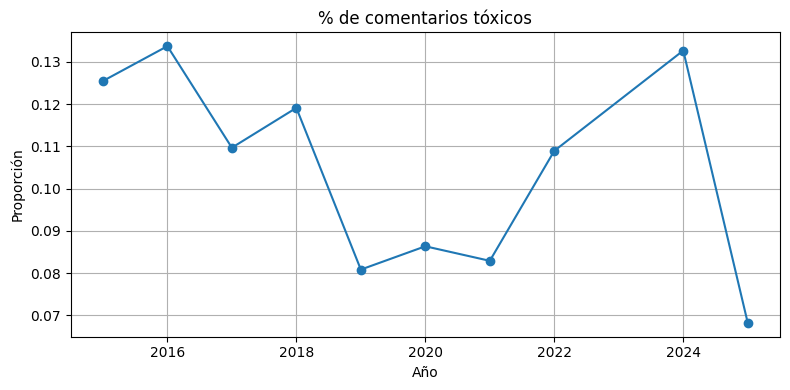

In [8]:
df_tox["tox_has_toxic"] = df_tox["tox_has_toxic"].astype(int)

percent_toxic = (
    df_tox.groupby("year")["tox_has_toxic"]
          .mean()
          .reset_index()
)

plt.figure(figsize=(8,4))
plt.plot(percent_toxic["year"], percent_toxic["tox_has_toxic"], marker="o")
plt.title("% de comentarios tóxicos")
plt.xlabel("Año")
plt.ylabel("Proporción")
plt.grid(True)
plt.tight_layout()
plt.show()


In [9]:
df_tox.to_csv(DATA_PROCESSED_DIR / "reddit_with_toxicity.csv", index=False)
tox_by_year.to_csv(DATA_PROCESSED_DIR / "toxicity_by_year.csv", index=False)

print("Guardado reddit_with_toxicity.csv")
print("Guardado toxicity_by_year.csv")


Guardado reddit_with_toxicity.csv
Guardado toxicity_by_year.csv
